<a href="https://colab.research.google.com/github/DiptanshuB/ICT6700-Assignment_1/blob/main/ICT_6700_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Healthcare Disease Prediction Using Machine Learning

### Special Study in ICT
### Topic: Federated AI Security for Healthcare

**Disease:** Breast Cancer  
**Algorithms:** Logistic Regression, SVM


## 1. Introduction

Machine Learning can be used in healthcare to assist in disease prediction and clinical decision support.

In this project, a breast cancer dataset is used to develop binary classification models. Logistic Regression and Support Vector Machine (SVM) are implemented as the primary classification algorithms.

The models are evaluated using Accuracy, Precision, Recall/Sensitivity, and Specificity.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [6]:
print("Feature names:")
print(data.feature_names)

print("\nTarget names:")
print(data.target_names)

Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target names:
['malignant' 'benign']


In [7]:
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [8]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (569, 31)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-

In [9]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [10]:
print("Missing values in each column:")

print(df.isnull().sum())

Missing values in each column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


### Observation

The dataset does not contain missing values, so no missing-value imputation was required.

In [11]:
print(df['target'].value_counts())

target
1    357
0    212
Name: count, dtype: int64


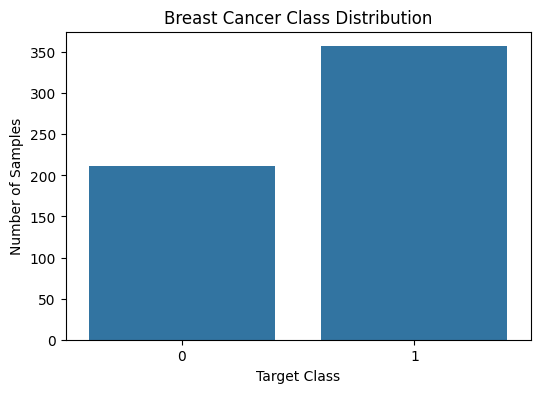

In [12]:
plt.figure(figsize=(6, 4))

sns.countplot(x='target', data=df)

plt.title('Breast Cancer Class Distribution')
plt.xlabel('Target Class')
plt.ylabel('Number of Samples')

plt.show()

In [13]:
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [16]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [17]:
y_pred_log = log_model.predict(X_test_scaled)

print("Prediction completed.")

Prediction completed.


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)

cm_log = confusion_matrix(y_test, y_pred_log)

TN, FP, FN, TP = cm_log.ravel()

specificity_log = TN / (TN + FP)

print("Logistic Regression Results")
print("----------------------------")
print("Accuracy:", accuracy_log)
print("Precision:", precision_log)
print("Recall/Sensitivity:", recall_log)
print("Specificity:", specificity_log)

Logistic Regression Results
----------------------------
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall/Sensitivity: 0.9861111111111112
Specificity: 0.9761904761904762


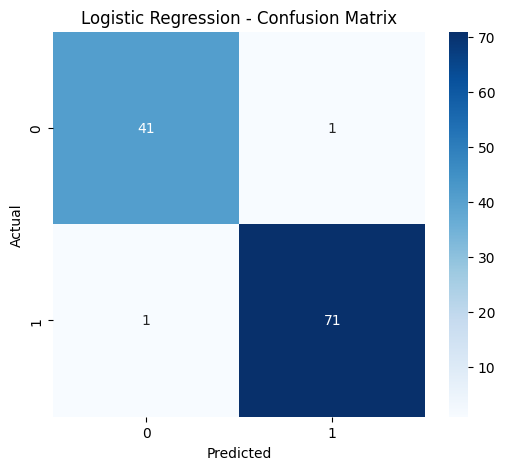

In [19]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [20]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')

svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [21]:
y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM prediction completed.")

SVM prediction completed.


In [22]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)

cm_svm = confusion_matrix(y_test, y_pred_svm)

TN, FP, FN, TP = cm_svm.ravel()

specificity_svm = TN / (TN + FP)

print("SVM Results")
print("-----------")
print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall/Sensitivity:", recall_svm)
print("Specificity:", specificity_svm)

SVM Results
-----------
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall/Sensitivity: 0.9861111111111112
Specificity: 0.9761904761904762


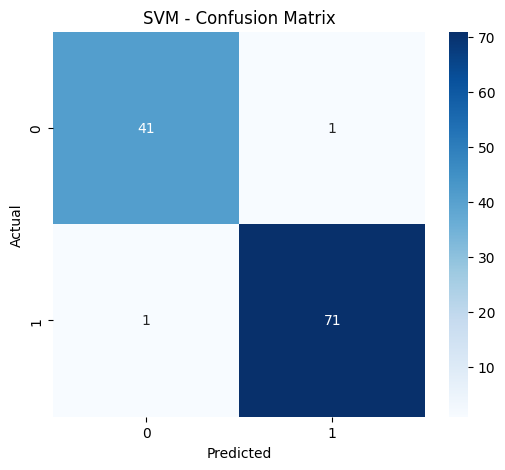

In [23]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('SVM - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [24]:
final_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall / Sensitivity',
        'Specificity'
    ],

    'Logistic Regression': [
        accuracy_log * 100,
        precision_log * 100,
        recall_log * 100,
        specificity_log * 100
    ],

    'SVM': [
        accuracy_svm * 100,
        precision_svm * 100,
        recall_svm * 100,
        specificity_svm * 100
    ]
})

final_results

,Metric,Logistic Regression,SVM
0,Accuracy,98.245614,98.245614
1,Precision,98.611111,98.611111
2,Recall / Sensitivity,98.611111,98.611111
3,Specificity,97.619048,97.619048


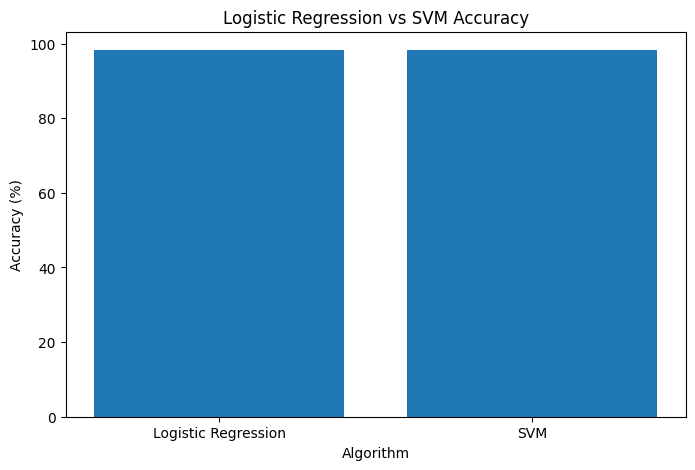

In [26]:
# Accuracy values from the models we have already trained

algorithms = [
    'Logistic Regression',
    'SVM'
]

accuracies = [
    accuracy_log * 100,
    accuracy_svm * 100
]

plt.figure(figsize=(8, 5))

plt.bar(algorithms, accuracies)

plt.title('Logistic Regression vs SVM Accuracy')
plt.xlabel('Algorithm')
plt.ylabel('Accuracy (%)')

plt.show()

## Conclusion

In this project, machine learning techniques were applied to a breast cancer classification problem.

Logistic Regression and Support Vector Machine (SVM) were implemented as the primary classification algorithms.

The models were evaluated using Accuracy, Precision, Recall/Sensitivity, and Specificity. Confusion matrices were used to analyze the classification results.

The comparison shows that model performance can vary depending on the algorithm and the characteristics of the dataset. In healthcare applications, relying only on accuracy may not be sufficient. Recall/Sensitivity and Specificity are particularly important because they indicate how effectively the model identifies positive and negative cases.

#Short Notes on Other Algorithms:


## Decision Tree:
A tree-based algorithm that makes predictions by splitting data into branches based on feature values.
##Random Forest:
An ensemble algorithm that combines multiple decision trees to improve prediction performance and reduce overfitting.
##K-Nearest Neighbors (KNN):
A classification algorithm that predicts a sample's class based on the classes of its nearest data points.